[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/viscoelastic-startup/blob/main/notebooks/christov_jordan_2012_second_grade_stokes2.ipynb)

# LEARNING OBJECTIVE

After exploring this notebook, you will be able to regenerate, from scratch, the corrected starting solutions for the transient version of Stokes' second problem (a suddenly oscillating plate) for a second-grade fluid, in a half-space and in a strip, given by [I. C. Christov & P. M. Jordan (2012)](https://arxiv.org/abs/1111.4464), and the erroneous solutions of Fetecau & Fetecau (2005) they correct. Furthermore, you will be able to verify them against a numerical inversion of the Laplace transform and a finite-difference scheme, reproduce Figs. 1 and 2 of that paper, see why the error cancels for a plate started as $\sin(\omega t)$ but not as $\cos(\omega t)$, and identify the problem the erroneous solutions actually solve.

The lesson of this pair of problems is that whether the error matters is decided in an instant by whether the plate's velocity jumps at $t = 0$.

# PRELIMINARIES

This notebook uses [NumPy](https://numpy.org) ([Harris _et al._, 2020](https://doi.org/10.1038/s41586-020-2649-2)), [SciPy](https://scipy.org) ([Virtanen _et al._, 2020](https://doi.org/10.1038/s41592-019-0686-2)), [SymPy](https://www.sympy.org) ([Meurer _et al._, 2017](https://doi.org/10.7717/peerj-cs.103)), [Matplotlib](https://matplotlib.org) ([Hunter, 2007](https://doi.org/10.1109/MCSE.2007.55)) and [mpmath](https://mpmath.org) ([mpmath development team, 2023](https://mpmath.org/)).

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# for animations
from IPython.display import HTML

# numerics
import numpy as np
from scipy.integrate import quad
from scipy.linalg import solve_banded
import mpmath as mp
import os

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version of this notebook written by [Ivan C. Christov](https://christov.tmnt-lab.org), Purdue University.

Reproducing results of I. C. Christov and P. M. Jordan.

# THE PROBLEM

The initial-boundary-value problem (IBVP) for the half-space, Eq. (1) of I. C. Christov & P. M. Jordan (2012), for the velocity $u(y,t)$ of a second-grade fluid above a plate that starts to oscillate at $t = 0^+$:
\begin{align*}
    \frac{\partial u}{\partial t} &= \nu \frac{\partial^2 u}{\partial y^2} + \alpha \frac{\partial^3 u}{\partial y\partial t\partial y}, & (y,t)\in(0,\infty)\times(0,\infty),\\
    u(0,t) &= U_0f(\omega t)H(t),\qquad u \to 0 \;\;\text{as}\;\; y\to\infty, & t>0,\\
    u(y,0) &= 0, & y>0,
\end{align*}
with $f(\cdot) = \cos(\cdot)$ or $\sin(\cdot)$, $H(t)$ the [Heaviside step function](https://en.wikipedia.org/wiki/Heaviside_step_function), $\nu$ the kinematic viscosity and $\alpha$ the first normal-stress modulus divided by the density. The strip problem, Eq. (9), is the same on $0 < y < d$ with $u(d,t) = 0$ (correcting the misprint in the published Eq. (9a), whose domain reads $(y,t)\in(0,\infty)\times(0,d)$ for $(0,d)\times(0,\infty)$ instead). With the dimensionless variables of the paper,
$$
    \tilde y = \frac{y}{\sqrt{\alpha}},\qquad \tilde t = \frac{\nu t}{\alpha},\qquad \Omega = \frac{\omega\alpha}{\nu},\qquad \tilde u = \frac{u}{U_0},\qquad l = \frac{\sqrt{\alpha}}{d},
$$
below $\nu = \alpha = U_0 = 1$ (so $\tilde y = y$, $\tilde t = t$, $\Omega = \omega$, $d = 1/l$). Figs. 1 and 2 of the paper use $f(\cdot) = \cos(\cdot)$, $\Omega = 2\pi$ and, for the strip, $l = 1$.

The plate velocity is $U_0f(\omega t)H(t)$, not $U_0f(\omega t)$: the plate is at rest until $t = 0$. Its derivative is therefore $U_0f(\omega t)\delta(t) + \omega U_0f^\prime(\omega t)H(t)$, and the first term survives only if $f(0) \ne 0$. For $f(\cdot) = \cos(\cdot)$ it does, $f(0) = 1$: the plate velocity jumps from $0$ to $U_0$ at $t = 0^+$, and dropping $U_0\cos(\omega t)\delta(t)$ changes the problem. 

For $f(\cdot) = \sin(\cdot)$ there is no jump, $f(0) = 0$, and $\mathcal{L}\{\sin(\omega t)\delta(t)\} = 0$: the neglected term contributes nothing, which is the "self-canceling error" that makes Eq. (3.9) right by luck. [Stokes (1850)](https://archive.org/details/b22464074/page/92/mode/2up), pp. 101&ndash;102 of his treatise, though lacking the Heaviside function and the operational calculus, was able to explain this difference gracefully for a Newtonian fluid.

In [2]:
# Generic helpers, used by the solutions of Fetecau & Fetecau (2005) below and by the correct ones
def sine_integral(g, y, t, omega, nu, alpha):
    """Integral of g(xi, t, omega, nu, alpha)*sin(xi*y) over 0 < xi < infinity."""
    # ordinary quadrature on (0, 1), then a Fourier-weighted rule for the slowly decaying tail
    head = quad(lambda xi: g(xi, t, omega, nu, alpha)*np.sin(xi*y), 0, 1, limit=200)[0]
    tail = quad(g, 1, np.inf, args=(t, omega, nu, alpha), weight='sin', wvar=y, limlst=200)[0]
    return head + tail

def denominator(xi, omega, nu, alpha):
    """nu^2 xi^4 + omega^2 (alpha xi^2 + 1)^2."""
    return nu**2*xi**4 + omega**2*(alpha*xi**2 + 1)**2

def decay(xi, t, nu, alpha):
    """exp(-nu xi^2 t/(1 + alpha xi^2))."""
    return np.exp(-nu*xi**2*t/(1 + alpha*xi**2))

# THE ERRONEOUS SOLUTIONS

> &#x26A0;&#xFE0F; **REPRODUCED AS PRINTED**: Eqs. (3.6), (3.9) and (4.6) of Fetecau & Fetecau (2005) ([doi:10.1016/j.ijengsci.2004.12.009](https://doi.org/10.1016/j.ijengsci.2004.12.009)), pp. 784&ndash;785. Their subsidiary equations, Eqs. (3.4) and (4.4), take $(\partial u/\partial t)(0,t) = -\omega U_0\sin(\omega t)$, dropping $U_0\cos(\omega t)\delta(t)$. It is shown below that Eqs. (3.6) and (4.6) are **erroneous**, while Eq. (3.9), the case $f(\cdot) = \sin(\cdot)$, for which the dropped term is zero, comes out right.

Half-space, $f(\cdot) = \cos(\cdot)$, Eq. (3.6) (their $V = U_0$):
\begin{align*}
    v(y,t) &= V\cos(\omega t) - \frac{2}{\pi}\omega^2V\cos(\omega t)\int_0^\infty \frac{\alpha\xi^2+1}{\xi[\nu^2\xi^4+\omega^2(\alpha\xi^2+1)^2]}\sin(y\xi)\,\mathrm{d}\xi\\
    &\quad + \frac{2}{\pi}\nu\omega V\sin(\omega t)\int_0^\infty\frac{\xi}{\nu^2\xi^4+\omega^2(\alpha\xi^2+1)^2}\sin(y\xi)\,\mathrm{d}\xi\\
    &\quad - \frac{2}{\pi}V\int_0^\infty\frac{\nu^2\xi^3+\alpha\omega^2\xi(\alpha\xi^2+1)}{\nu^2\xi^4+\omega^2(\alpha\xi^2+1)^2}\exp\left(-\frac{\nu\xi^2}{1+\alpha\xi^2}t\right)\sin(y\xi)\,\mathrm{d}\xi.
\end{align*}
Half-space, $f(\cdot) = \sin(\cdot)$, Eq. (3.9):
\begin{align*}
    v(y,t) &= V\sin(\omega t) - \frac{2}{\pi}\nu\omega V\cos(\omega t)\int_0^\infty\frac{\xi}{\nu^2\xi^4+\omega^2(\alpha\xi^2+1)^2}\sin(y\xi)\,\mathrm{d}\xi\\
    &\quad - \frac{2}{\pi}\omega^2V\sin(\omega t)\int_0^\infty \frac{\alpha\xi^2+1}{\xi[\nu^2\xi^4+\omega^2(\alpha\xi^2+1)^2]}\sin(y\xi)\,\mathrm{d}\xi\\
    &\quad + \frac{2}{\pi}\nu\omega V\int_0^\infty\frac{\xi}{\nu^2\xi^4+\omega^2(\alpha\xi^2+1)^2}\exp\left(-\frac{\nu\xi^2}{1+\alpha\xi^2}t\right)\sin(y\xi)\,\mathrm{d}\xi.
\end{align*}
Strip, $f(\cdot) = \cos(\cdot)$, Eq. (4.6), with $\lambda_n = n\pi/d$:
\begin{align*}
    v(y,t) &= V\left(1-\frac{y}{d}\right)\cos(\omega t) + \frac{2\omega V}{d}\sum_{n=1}^\infty\frac{\nu\lambda_n^2\sin(\omega t) - \omega(\alpha\lambda_n^2+1)\cos(\omega t)}{\lambda_n[\nu^2\lambda_n^4+\omega^2(\alpha\lambda_n^2+1)^2]}\sin(\lambda_n y)\\
    &\quad - \frac{2V}{d}\sum_{n=1}^\infty\frac{\lambda_n[(\nu\lambda_n)^2+\alpha\omega^2(\alpha\lambda_n^2+1)]}{\nu^2\lambda_n^4+\omega^2(\alpha\lambda_n^2+1)^2}\exp\left(-\frac{\nu\lambda_n^2}{1+\alpha\lambda_n^2}t\right)\sin(\lambda_n y).
\end{align*}

In [3]:
# WRONG, as printed: Eqs. (3.6), (3.9) and (4.6) of Fetecau & Fetecau (2005), with V = 1
def g_a(xi, t, omega, nu, alpha):
    """(alpha xi^2 + 1)/(xi D), from Eqs. (3.6) and (3.9) of Fetecau & Fetecau (2005)."""
    return (alpha*xi**2 + 1)/(xi*denominator(xi, omega, nu, alpha))

def g_b(xi, t, omega, nu, alpha):
    """xi/D, from Eqs. (3.6) and (3.9) of Fetecau & Fetecau (2005)."""
    return xi/denominator(xi, omega, nu, alpha)

def g_c(xi, t, omega, nu, alpha):
    """Transient integrand of Eq. (3.6) of Fetecau & Fetecau (2005)."""
    return (nu**2*xi**3 + alpha*omega**2*xi*(alpha*xi**2 + 1))/denominator(xi, omega, nu, alpha)*decay(xi, t, nu, alpha)

def g_d(xi, t, omega, nu, alpha):
    """Transient integrand of Eq. (3.9) of Fetecau & Fetecau (2005)."""
    return xi/denominator(xi, omega, nu, alpha)*decay(xi, t, nu, alpha)

def wrong_fetecau_fetecau_36(y, t, omega, nu=1.0, alpha=1.0):
    """Erroneous solution, as printed: Eq. (3.6) of Fetecau & Fetecau (2005), f = cos, half-space."""
    if y == 0:
        return np.cos(omega*t)   # sin(0) = 0, so the formula gives the plate velocity exactly
    return (np.cos(omega*t) - 2/np.pi*omega**2*np.cos(omega*t)*sine_integral(g_a, y, t, omega, nu, alpha)
            + 2/np.pi*nu*omega*np.sin(omega*t)*sine_integral(g_b, y, t, omega, nu, alpha)
            - 2/np.pi*sine_integral(g_c, y, t, omega, nu, alpha))

def fetecau_fetecau_39(y, t, omega, nu=1.0, alpha=1.0):
    """Solution as printed in Eq. (3.9) of Fetecau & Fetecau (2005), f = sin, half-space."""
    if y == 0:
        return np.sin(omega*t)
    return (np.sin(omega*t) - 2/np.pi*nu*omega*np.cos(omega*t)*sine_integral(g_b, y, t, omega, nu, alpha)
            - 2/np.pi*omega**2*np.sin(omega*t)*sine_integral(g_a, y, t, omega, nu, alpha)
            + 2/np.pi*nu*omega*sine_integral(g_d, y, t, omega, nu, alpha))

def wrong_fetecau_fetecau_46(y, t, omega, d, nterms=100, nu=1.0, alpha=1.0):
    """Erroneous solution, as printed: Eq. (4.6) of Fetecau & Fetecau (2005), f = cos, strip 0 < y < d."""
    v = (1 - y/d)*np.cos(omega*t)
    for n in range(1, nterms + 1):
        lam = n*np.pi/d
        D = nu**2*lam**4 + omega**2*(alpha*lam**2 + 1)**2
        v = v + 2*omega/d*(nu*lam**2*np.sin(omega*t) - omega*(alpha*lam**2 + 1)*np.cos(omega*t))/(lam*D)*np.sin(lam*y)
        v = v - 2/d*lam*((nu*lam)**2 + alpha*omega**2*(alpha*lam**2 + 1))/D*np.exp(-nu*lam**2*t/(1 + alpha*lam**2))*np.sin(lam*y)
    return v

> &#x26A0;&#xFE0F; **END OF THE ERRONEOUS SOLUTIONS.** The cells below are correct.

# THE CORRECT SOLUTION

With the [Dirac delta](https://en.wikipedia.org/wiki/Dirac_delta_function), the plate acceleration is, Eqs. (3) and (6),
$$
    \frac{\partial u}{\partial t}(0,t) = U_0f(\omega t)\delta(t) + \omega U_0f'(\omega t)H(t).
$$
The Fourier sine transform $\bar{u}_\mathrm{s}(\xi,t) = \int_0^\infty u\sin(\xi y)\,\mathrm{d}y$ followed by the [Laplace transform](https://en.wikipedia.org/wiki/Laplace_transform) gives, Eqs. (4) and (7),
\begin{align*}
    \overline{u_{\mathrm{s}}}(\xi,s) &= \frac{U_0\xi}{s(1+\alpha\xi^2) + \nu\xi^2}\left(\frac{\nu s - \alpha\omega^2}{s^2+\omega^2} + \alpha \right), && f=\cos,\\
    \overline{u_{\mathrm{s}}}(\xi,s) &= \frac{U_0\xi}{s(1+\alpha\xi^2) + \nu\xi^2}\left(\frac{\nu\omega + \alpha \omega s}{s^2+\omega^2} \right), && f=\sin.
\end{align*}
The next cell derives both with SymPy, with and without the $\delta(t)$ term; it should print Eq. (4), the wrong transform for $f(\cdot) = \cos(\cdot)$ (without the $+\alpha$), and $0$ for the difference of the two $f(\cdot) = \sin(\cdot)$ transforms (the "self-canceling error").

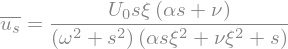

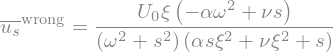

In [4]:
# Eqs. (3), (4), (6), (7) of I. C. Christov & P. M. Jordan (2012), with and without the delta term
t = sp.Symbol('t', real=True)   # not positive=True, otherwise SymPy sets DiracDelta(t) = 0
s, xi, nu, alpha, omega, U0 = sp.symbols('s xi nu alpha omega U_0', positive=True)
w = sp.Function('w')
W, w0 = sp.symbols(r'\overline{u_s} w_0')

def laplace(expr):
    """Laplace transform in t, with W and w(0) as symbols."""
    L = sp.laplace_transform(expr, t, s, noconds=True)
    L = L.subs(sp.LaplaceTransform(w(t), t, s), W).subs(w(0), w0)
    return sp.expand(L)

def transform(plate, keep_delta):
    """Fourier-Laplace transform of the solution for the plate velocity U0 plate(t) H(t)."""
    boundary = U0*plate*sp.Heaviside(t)
    if keep_delta:
        plate_acceleration = sp.diff(boundary, t)
    else:
        plate_acceleration = U0*sp.diff(plate, t)*sp.Heaviside(t)   # the delta dropped, as in Fetecau & Fetecau
    rhs = nu*(-xi**2*w(t) + xi*boundary) + alpha*(-xi**2*w(t).diff(t) + xi*plate_acceleration)
    return sp.solve(laplace(rhs - w(t).diff(t)).subs(w0, 0), W)[0]

W_cos = transform(sp.cos(omega*t), True)
W_cos_wrong = transform(sp.cos(omega*t), False)
W_sin = transform(sp.sin(omega*t), True)
W_sin_wrong = transform(sp.sin(omega*t), False)
display(sp.Eq(W, sp.factor(W_cos)))
display(sp.Eq(sp.Symbol(r'\overline{u_s}^\mathrm{wrong}'), sp.factor(W_cos_wrong)))
display(sp.simplify(W_sin - W_sin_wrong))

Inverting gives, for the half-space, Eq. (5) ($f(\cdot) = \cos(\cdot)$ ),
\begin{align*}
    &u(y,t) = U_0H(t)\Bigg(\frac{2}{\pi}\int_0^\infty \frac{\xi\sin(y\xi)}{\nu^2\xi^4 + \omega^2(1 + \alpha\xi^2)^2}\\
    &\quad\times \left\{ -\frac{\nu^2\xi^2}{1 + \alpha\xi^2}\exp\left(-\frac{\nu\xi^2}{1 + \alpha\xi^2}t\right) + \nu\omega \sin(\omega t) + \left[\nu^2\xi^2 + \alpha \omega^2 (1 + \alpha\xi^2)\right] \cos(\omega t) \right\}  \,\mathrm{d}\xi \Bigg),
\end{align*}
and, for $f(\cdot) = \sin(\cdot)$, Eq. (8),
\begin{align*}
    & u(y,t) = U_0H(t)\Bigg( \frac{2}{\pi} \int_0^\infty \frac{\xi\sin(y\xi)}{\nu^2\xi^4 + \omega^2(1+ \alpha\xi^2)^2} \\
    &\quad\times \left\{ \nu\omega\exp\left(-\frac{\nu\xi^2}{1 + \alpha\xi^2}t\right)
     - \nu\omega \cos(\omega t) + \left[\nu^2 \xi^2 + \alpha \omega^2 (1 + \alpha\xi^2) \right] \sin(\omega t) \right\}\mathrm{d}\xi \Bigg).
\end{align*}
The integrals are evaluated with [`scipy.integrate.quad`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) (the paper used _Mathematica_'s `NIntegrate`).

In [5]:
# Eqs. (5) and (8) of I. C. Christov & P. M. Jordan (2012): half-space, f = cos and f = sin
def g_cos(xi, t, omega, nu, alpha):
    """Integrand of Eq. (5) without sin(y xi)."""
    bracket = (-nu**2*xi**2/(1 + alpha*xi**2)*decay(xi, t, nu, alpha) + nu*omega*np.sin(omega*t)
               + (nu**2*xi**2 + alpha*omega**2*(1 + alpha*xi**2))*np.cos(omega*t))
    return xi/denominator(xi, omega, nu, alpha)*bracket

def g_sin(xi, t, omega, nu, alpha):
    """Integrand of Eq. (8) without sin(y xi)."""
    bracket = (nu*omega*decay(xi, t, nu, alpha) - nu*omega*np.cos(omega*t)
               + (nu**2*xi**2 + alpha*omega**2*(1 + alpha*xi**2))*np.sin(omega*t))
    return xi/denominator(xi, omega, nu, alpha)*bracket

def unsteadyv(y, t, omega, nu=1.0, alpha=1.0):
    """Correct solution, Eq. (5) of I. C. Christov & P. M. Jordan (2012), f = cos, half-space, U0 = 1."""
    if y == 0:
        return np.cos(omega*t)   # sin(0) = 0, so the formula gives the plate velocity exactly
    return 2/np.pi*sine_integral(g_cos, y, t, omega, nu, alpha)

def unsteadyv_sin(y, t, omega, nu=1.0, alpha=1.0):
    """Correct solution, Eq. (8) of I. C. Christov & P. M. Jordan (2012), f = sin, half-space, U0 = 1."""
    if y == 0:
        return np.sin(omega*t)
    return 2/np.pi*sine_integral(g_sin, y, t, omega, nu, alpha)

def profile(func, y, t, omega):
    """Evaluate a point-wise solution func(y, t, omega) on an array of y."""
    u = np.zeros_like(y)
    for j in range(len(y)):
        u[j] = func(y[j], t, omega)
    return u

For the strip, using only the Laplace transform in $t$ ([Jordan, 2005](https://doi.org/10.1155/MPE.2005.539)), the transform of the solution is Eq. (10), with $\kappa = \nu/\alpha$,
$$
    \bar{u}(y,s)=\frac{U_0\sinh\left[\left(1-ly/\sqrt{\alpha}\right)\sqrt{s/(l^2\kappa + sl^2)}\right]}{\sinh\left[\sqrt{s/(l^2\kappa + sl^2)}\right]}
    \times\begin{cases}
        s/(s^2+\omega^2), & f =\cos,\\
        \omega/(s^2+\omega^2), & f=\sin,
    \end{cases}
$$
and the solutions are Eq. (11) for $f(\cdot) = \sin(\cdot)$ and Eq. (12) for $f(\cdot) = \cos(\cdot)$, with $\sigma_n = l^2n^2\pi^2(1+l^{2}n^2\pi^2)^{-1}$ and $\omega t = \Omega\tilde t$:
\begin{align*}
    &u(\tilde y,\tilde t) = U_{0}H(\tilde t)\Bigg\{\sin(\omega t)\left(1 - l\tilde y\right)\\
    &\qquad+\frac{2\Omega}{\pi}\sum_{n=1}^{\infty}
    \left[\frac{\sigma_n\exp(-\sigma_n\tilde t) - \sigma_n\cos(\Omega \tilde t) - \Omega\sin(\Omega \tilde t)}{\sigma_n^2 + \Omega^2}\right]\frac{\sin(l n\pi \tilde y)}{n(1+l^{2}n^2\pi^2)} \Bigg\},
\end{align*}

\begin{align*}
    &u(\tilde y,\tilde t) = U_{0}H(\tilde t)\Bigg\{\cos(\omega t)\left(1 - l\tilde y \right)\\
    &\qquad-\frac{2}{\pi}\sum_{n=1}^{\infty}
    \left[\frac{\sigma_n^2\exp(-\sigma_n\tilde t) - \sigma_n\Omega\sin(\Omega \tilde t) + \Omega^2 \cos(\Omega \tilde t)}{\sigma_n^2 + \Omega^2}\right]\frac{\sin(l n\pi \tilde y)}{n(1+l^{2}n^2\pi^2)} \Bigg\}.
\end{align*}

In [6]:
# Eqs. (11) and (12) of I. C. Christov & P. M. Jordan (2012): strip, f = sin and f = cos (y, t, Omega dimensionless)
def strip_sin_11(y, t, Omega, l, nterms=100):
    """Correct solution, Eq. (11) of I. C. Christov & P. M. Jordan (2012), f = sin, strip."""
    u = np.sin(Omega*t)*(1 - l*y)
    for n in range(1, nterms + 1):
        sigma = l**2*n**2*np.pi**2/(1 + l**2*n**2*np.pi**2)
        bracket = (sigma*np.exp(-sigma*t) - sigma*np.cos(Omega*t) - Omega*np.sin(Omega*t))/(sigma**2 + Omega**2)
        u = u + 2*Omega/np.pi*bracket*np.sin(l*n*np.pi*y)/(n*(1 + l**2*n**2*np.pi**2))
    return u

def strip_cos_12(y, t, Omega, l, nterms=100):
    """Correct solution, Eq. (12) of I. C. Christov & P. M. Jordan (2012), f = cos, strip."""
    u = np.cos(Omega*t)*(1 - l*y)
    for n in range(1, nterms + 1):
        sigma = l**2*n**2*np.pi**2/(1 + l**2*n**2*np.pi**2)
        bracket = (sigma**2*np.exp(-sigma*t) - sigma*Omega*np.sin(Omega*t) + Omega**2*np.cos(Omega*t))/(sigma**2 + Omega**2)
        u = u - 2/np.pi*bracket*np.sin(l*n*np.pi*y)/(n*(1 + l**2*n**2*np.pi**2))
    return u

Note that the long-time limit of these solutions is _not_ a "steady state," as Fetecau & Fetecau (2005) call it: it is not independent of time. Once the transient has decayed &mdash; the terms carrying $\exp[-\nu\xi^2 t/(1+\alpha\xi^2)]$ in the half-space, and $\exp(-\sigma_n\tilde t)$ in the strip &mdash; what remains is a post-transient _periodic_ state, oscillating with the plate at the frequency $\omega$. The distinction matters for the error, too: the difference between the erroneous and the correct solutions decays like $\mathrm{e}^{-\nu t/\alpha}$, so it lives entirely in the transient, and at long times the wrong solution settles into the same periodic state as the right one.

# AN INDEPENDENT CHECK

Two independent checks. First, the Laplace-domain solutions (half-space: $\bar{u}(y,s) = \bar{U}(s)\exp\left(-y\sqrt{s/(\nu + \alpha s)}\right)$ with $\bar{U} = s/(s^2+\omega^2)$ or $\omega/(s^2+\omega^2)$; strip: Eq. (10)) inverted numerically by the algorithm of [de Hoog _et al._ (1982)](https://doi.org/10.1137/0903022) in [mpmath's `invertlaplace`](https://mpmath.org/doc/current/calculus/inverselaplace.html). Second, the finite-difference scheme of Eqs. (4)&ndash;(5) of [I. C. Christov & C. I. Christov (2010)](https://arxiv.org/abs/1003.2188), with the plate velocity $U_0f(\omega t^n)$ for $n \ge 1$ and $0$ at $n = 0$, and their parameters ($M = 5000$, $K = 1000$, $L = 20$; $L = d$ for the strip).

In [7]:
# Laplace-domain solutions for the half-space and for the strip, Eq. (10), inverted by de Hoog's algorithm (nu = alpha = 1)
def plate_bar(s, kind, omega):
    """Laplace transform of the plate velocity cos(omega t) or sin(omega t)."""
    if kind == 'cos':
        return s/(s**2 + omega**2)
    return omega/(s**2 + omega**2)

def dehoog_half_space(y, t, omega, kind):
    """Half-space solution inverted by de Hoog's algorithm, point by point in y."""
    u = np.zeros_like(y)
    for j in range(len(y)):
        u[j] = float(mp.invertlaplace(lambda s: plate_bar(s, kind, omega)*mp.exp(-y[j]*mp.sqrt(s/(1 + s))), t, method='dehoog'))
    return u

def strip_bar(s, y, l):
    """sinh[(1 - l y) z]/sinh(z), z = sqrt(s/(l^2 kappa + s l^2)), kappa = 1, from Eq. (10)."""
    z = mp.sqrt(s/(l**2 + s*l**2))
    return mp.sinh((1 - l*y)*z)/mp.sinh(z)

def dehoog_strip(y, t, omega, kind, l):
    """Strip solution, Eq. (10), inverted by de Hoog's algorithm, point by point in y."""
    u = np.zeros_like(y)
    for j in range(len(y)):
        u[j] = float(mp.invertlaplace(lambda s: plate_bar(s, kind, omega)*strip_bar(s, y[j], l), t, method='dehoog'))
    return u

In [8]:
# Eqs. (4)-(5) of I. C. Christov & C. I. Christov (2010): finite-difference scheme, here with an oscillating plate
def sg_fd(nu, alpha, tf, L=20.0, M=5000, K=1000, ramp_time=0.0, v00=0.0, oscillation='', omega=0.0, gamma=0.0):
    """Scheme of Eq. (4) with the boundary conditions of Eq. (5) of I. C. Christov & C. I. Christov (2010), V0 = 1."""
    # ramp_time > 0 moves the plate with 1 - exp(-t/ramp_time) instead of 1; oscillation = 'cos' or 'sin'
    # moves it with cos(omega t) or sin(omega t); v00 is the plate velocity at n = 0;
    # gamma > 0 adds the porous-medium term, d^2/dy^2 -> d^2/dy^2 - gamma^2
    dy = L/(M - 1)
    dt = tf/(K - 1)
    y = np.linspace(0, L, M)
    v = np.zeros(M)
    v[0] = v00
    a = alpha/dy**2
    b = nu*dt/(2*dy**2)
    # tridiagonal matrix of (1 - (alpha + nu dt/2) delta^2/dy^2) acting on the interior points
    ab = np.zeros((3, M-2))
    ab[0, 1:] = -(a + b)
    ab[1, :] = 1 + 2*(a + b) + (alpha + nu*dt/2)*gamma**2
    ab[2, :-1] = -(a + b)
    for n in range(1, K):
        if ramp_time > 0:
            plate = 1 - np.exp(-n*dt/ramp_time)
        elif oscillation == 'cos':
            plate = np.cos(omega*n*dt)
        elif oscillation == 'sin':
            plate = np.sin(omega*n*dt)
        else:
            plate = 1.0
        rhs = v[1:-1] - (a - b)*(v[2:] - 2*v[1:-1] + v[:-2]) + (alpha - nu*dt/2)*gamma**2*v[1:-1]
        rhs[0] = rhs[0] + (a + b)*plate
        v_new = np.zeros(M)
        v_new[0] = plate
        v_new[1:-1] = solve_banded((1, 1), ab, rhs)
        v = v_new
    return y, v

The next cell prints the checks, with $\Omega = 2\pi$:

* for $\Omega = 0$, when Eq. (5) reduces to Stokes' first problem, Eq. (3) of I. C. Christov & C. I. Christov (2010) (should be at the quadrature tolerance);
* half-space, $\tilde t = 1$ and $3.5$: Eqs. (5) and (8) against de Hoog's inversion (about $10^{-10}$) and the scheme; Eq. (3.9) of Fetecau & Fetecau (2005) against Eq. (8) (they are equal: the self-canceling error); the error of Eq. (3.6), its minimum (a back-flow), and its value at the wall, $\cos(\Omega\tilde t) - \mathrm{e}^{-\tilde t}$ instead of $\cos(\Omega\tilde t)$; and the convergence of the scheme as $M$ and $K$ are doubled together (formally $O[(\Delta t)^2 + (\Delta y)^2]$, but first order in practice, because of the start-up jump);
* strip, $l = 1$, $\tilde t = 1$ and $2.5$: Eqs. (11) and (12) against de Hoog's inversion and the scheme, and the error of Eq. (4.6); convergence in the number of terms.

Where a convergence table prints a number in parentheses, it is the estimated order of convergence, $\log_2$ of the ratio of successive errors.

In [9]:
# Checks for I. C. Christov & P. M. Jordan (2012)
Omega = 2*np.pi
print('LIMIT Omega = 0 (should be at the quadrature tolerance)')
y_limit = np.array([0.2, 0.5, 1.0])
def g_first(xi, t, omega, nu, alpha):
    """Integrand of Eq. (3) of Christov & Christov (2010), combined into one integral."""
    return decay(xi, t, nu, alpha)/(xi*(1 + alpha*xi**2))

first_problem = np.zeros_like(y_limit)
for j in range(len(y_limit)):
    first_problem[j] = 1 - 2/np.pi*sine_integral(g_first, y_limit[j], 0.5, 0.0, 1.0, 1.0)
print(f'  max|Eq. (5) at Omega = 0 - Eq. (3) of Christov & Christov (2010)| = {np.abs(profile(unsteadyv, y_limit, 0.5, 0.0) - first_problem).max():.1e}')

y = np.linspace(0.05, 3, 25)
for t in [1.0, 3.5]:
    print(f'\nHALF-SPACE, t~ = {t}, max over 0.05 <= y~ <= 3')
    u_cos = profile(unsteadyv, y, t, Omega)
    u_sin = profile(unsteadyv_sin, y, t, Omega)
    print(f'  Eq. (5) vs de Hoog: {np.abs(u_cos - dehoog_half_space(y, t, Omega, "cos")).max():.1e}')
    print(f'  Eq. (8) vs de Hoog: {np.abs(u_sin - dehoog_half_space(y, t, Omega, "sin")).max():.1e}')
    assert np.abs(u_sin - dehoog_half_space(y, t, Omega, "sin")).max() < 1e-6   # a regression guard: the notebook stops here if a future edit breaks the agreement
    y_fd, u_fd = sg_fd(1.0, 1.0, t, oscillation='cos', omega=Omega)
    print(f'  Eq. (5) vs scheme, M = 5000, K = 1000: {np.abs(u_cos - np.interp(y, y_fd, u_fd)).max():.1e}')
    y_fd, u_fd = sg_fd(1.0, 1.0, t, oscillation='sin', omega=Omega)
    print(f'  Eq. (8) vs scheme, M = 5000, K = 1000: {np.abs(u_sin - np.interp(y, y_fd, u_fd)).max():.1e}')
    print(f'  Eq. (3.9) of Fetecau & Fetecau vs Eq. (8): {np.abs(profile(fetecau_fetecau_39, y, t, Omega) - u_sin).max():.1e}')
    u_wrong = profile(wrong_fetecau_fetecau_36, y, t, Omega)
    print(f'  erroneous Eq. (3.6) - Eq. (5): {np.abs(u_wrong - u_cos).max():.2f}; min of Eq. (3.6): {u_wrong.min():.3f}')
    print(f'  at y~ = 1e-5: Eq. (3.6) = {wrong_fetecau_fetecau_36(1e-5, t, Omega):.5f}, '
          f'cos(Omega t~) - exp(-t~) = {np.cos(Omega*t) - np.exp(-t):.5f}, cos(Omega t~) = {np.cos(Omega*t):.5f}')
    print('  convergence of the scheme versus Eq. (5):')
    print('    grid: max error (estimated order of convergence)')
    # the estimated order of convergence is log2 of the ratio of successive errors, since the grid is halved
    previous = None
    for M, K in [(1250, 250), (2500, 500), (5000, 1000)]:
        y_fd, u_fd = sg_fd(1.0, 1.0, t, M=M, K=K, oscillation='cos', omega=Omega)
        error = np.abs(u_cos - np.interp(y, y_fd, u_fd)).max()
        if previous is None:
            print(f'    M = {M:5d}, K = {K:4d}: {error:.1e}')
        else:
            print(f'    M = {M:5d}, K = {K:4d}: {error:.1e} ({np.log2(previous/error):.2f})')
        previous = error

l = 1.0
y = np.linspace(0.05, 0.95, 19)
for t in [1.0, 2.5]:
    print(f'\nSTRIP, l = {l}, t~ = {t}, max over 0.05 <= y~ <= 0.95')
    u_12 = strip_cos_12(y, t, Omega, l, 100)
    u_11 = strip_sin_11(y, t, Omega, l, 100)
    print(f'  Eq. (12), 100 terms, vs de Hoog: {np.abs(u_12 - dehoog_strip(y, t, Omega, "cos", l)).max():.1e}')
    print(f'  Eq. (11), 100 terms, vs de Hoog: {np.abs(u_11 - dehoog_strip(y, t, Omega, "sin", l)).max():.1e}')
    y_fd, u_fd = sg_fd(1.0, 1.0, t, L=1/l, M=2000, K=1000, oscillation='cos', omega=Omega)
    print(f'  Eq. (12) vs scheme, M = 2000, K = 1000: {np.abs(u_12 - np.interp(y, y_fd, u_fd)).max():.1e}')
    print(f'  erroneous Eq. (4.6), 100 terms, - Eq. (12): {np.abs(wrong_fetecau_fetecau_46(y, t, Omega, 1/l, 100) - u_12).max():.2f}')
    print('  convergence in the number of terms (versus 4000 terms), Eq. (12) and Eq. (4.6):')
    for nterms in [25, 100, 400]:
        e12 = np.abs(strip_cos_12(y, t, Omega, l, nterms) - strip_cos_12(y, t, Omega, l, 4000)).max()
        e46 = np.abs(wrong_fetecau_fetecau_46(y, t, Omega, 1/l, nterms) - wrong_fetecau_fetecau_46(y, t, Omega, 1/l, 4000)).max()
        print(f'    {nterms:4d} terms: {e12:.1e}   {e46:.1e}')

LIMIT Omega = 0 (should be at the quadrature tolerance)
  max|Eq. (5) at Omega = 0 - Eq. (3) of Christov & Christov (2010)| = 4.4e-11

HALF-SPACE, t~ = 1.0, max over 0.05 <= y~ <= 3
  Eq. (5) vs de Hoog: 3.0e-11


  Eq. (8) vs de Hoog: 3.6e-11


  Eq. (5) vs scheme, M = 5000, K = 1000: 5.8e-05
  Eq. (8) vs scheme, M = 5000, K = 1000: 1.9e-07
  Eq. (3.9) of Fetecau & Fetecau vs Eq. (8): 6.3e-10
  erroneous Eq. (3.6) - Eq. (5): 0.36; min of Eq. (3.6): -0.015
  at y~ = 1e-5: Eq. (3.6) = 0.63212, cos(Omega t~) - exp(-t~) = 0.63212, cos(Omega t~) = 1.00000
  convergence of the scheme versus Eq. (5):
    grid: max error (estimated order of convergence)
    M =  1250, K =  250: 2.3e-04
    M =  2500, K =  500: 1.2e-04 (0.98)


    M =  5000, K = 1000: 5.8e-05 (0.99)

HALF-SPACE, t~ = 3.5, max over 0.05 <= y~ <= 3


  Eq. (5) vs de Hoog: 7.4e-10
  Eq. (8) vs de Hoog: 1.2e-10


  Eq. (5) vs scheme, M = 5000, K = 1000: 9.8e-05
  Eq. (8) vs scheme, M = 5000, K = 1000: 1.5e-06
  Eq. (3.9) of Fetecau & Fetecau vs Eq. (8): 3.6e-10
  erroneous Eq. (3.6) - Eq. (5): 0.08; min of Eq. (3.6): -0.985
  at y~ = 1e-5: Eq. (3.6) = -1.03019, cos(Omega t~) - exp(-t~) = -1.03020, cos(Omega t~) = -1.00000
  convergence of the scheme versus Eq. (5):
    grid: max error (estimated order of convergence)
    M =  1250, K =  250: 4.0e-04
    M =  2500, K =  500: 2.0e-04 (1.01)


    M =  5000, K = 1000: 9.8e-05 (1.01)

STRIP, l = 1.0, t~ = 1.0, max over 0.05 <= y~ <= 0.95
  Eq. (12), 100 terms, vs de Hoog: 3.9e-07


  Eq. (11), 100 terms, vs de Hoog: 3.8e-08
  Eq. (12) vs scheme, M = 2000, K = 1000: 1.1e-05
  erroneous Eq. (4.6), 100 terms, - Eq. (12): 0.36
  convergence in the number of terms (versus 4000 terms), Eq. (12) and Eq. (4.6):
      25 terms: 1.8e-05   4.4e-02
     100 terms: 3.9e-07   1.5e-02
     400 terms: 6.3e-09   3.3e-03

STRIP, l = 1.0, t~ = 2.5, max over 0.05 <= y~ <= 0.95


  Eq. (12), 100 terms, vs de Hoog: 3.8e-07
  Eq. (11), 100 terms, vs de Hoog: 6.6e-08


  Eq. (12) vs scheme, M = 2000, K = 1000: 6.8e-06
  erroneous Eq. (4.6), 100 terms, - Eq. (12): 0.08
  convergence in the number of terms (versus 4000 terms), Eq. (12) and Eq. (4.6):
      25 terms: 1.8e-05   9.8e-03
     100 terms: 3.8e-07   3.4e-03
     400 terms: 6.2e-09   7.5e-04


# THE PAPER'S FIGURES

This is Fig. 1 of I. C. Christov & P. M. Jordan (2012): $\tilde u$ versus $\tilde y$ for the half-space with $f(\cdot) = \cos(\cdot)$ and $\Omega = 2\pi$ at (a) $\tilde t = 1$ and (b) $\tilde t = 3.5$, with the incorrect Eq. (3.6) of Fetecau & Fetecau (2005) dashed, the correct Eq. (5) solid and the numerical solution dotted. Each panel keeps the published range extended by $0.05$ past the correct solution, so that the excursions of Eq. (3.6) beyond it are not clipped: the back-flow in (a) and the overshoot past the plate speed in (b).

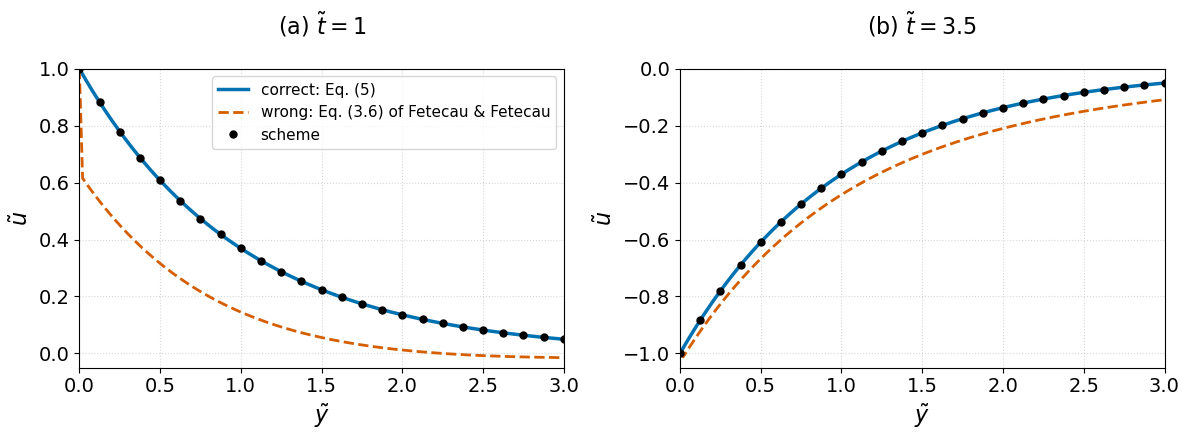

In [10]:
# Fig. 1 of I. C. Christov & P. M. Jordan (2012)
Omega = 2*np.pi
panels = [(1.0, -0.05, 1.0), (3.5, -1.05, 0.0)]   # t~, lower and upper limits of u~; the published
                                                # ranges, each extended by 0.05 past the correct
                                                # solution, so that Eq. (3.6) is not clipped
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), tight_layout=True)
for k in range(2):
    t, u_low, u_high = panels[k]
    ax = axes[k]
    y = np.linspace(0, 3, 150)
    y_fd, u_fd = sg_fd(1.0, 1.0, t, oscillation='cos', omega=Omega)
    y_dots = np.linspace(0, 3, 25)
    ax.plot(y, profile(unsteadyv, y, t, Omega), 
            color='#0072B2', linewidth=2.5, label='correct: Eq. (5)')
    ax.plot(y, profile(wrong_fetecau_fetecau_36, y, t, Omega), 
            color='#D55E00', linewidth=2, linestyle='dashed',
            label='wrong: Eq. (3.6) of Fetecau & Fetecau')
    ax.plot(y_dots, np.interp(y_dots, y_fd, u_fd), 'o', 
            color='black', markersize=5, label='scheme')
    ax.set_xlabel(r'$\tilde y$')
    ax.set_ylabel(r'$\tilde u$')
    ax.set_xlim(0, 3)
    ax.set_ylim(u_low, u_high)
    ax.set_title(rf'({"ab"[k]}) $\tilde t = {t:g}$')
    ax.grid(alpha=0.5, linestyle='dotted')
axes[0].legend(loc='upper right', fontsize=11)
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/christov_jordan_2012_fig1.png', dpi=200, bbox_inches='tight')

This is Fig. 2 of I. C. Christov & P. M. Jordan (2012): $\tilde u$ versus $\tilde y$ for the strip with $l = 1$, $f(\cdot) = \cos(\cdot)$ and $\Omega = 2\pi$ at (a) $\tilde t = 1$ and (b) $\tilde t = 2.5$, with 100 terms of the incorrect Eq. (4.6) of Fetecau & Fetecau (2005) dashed, 100 terms of the correct Eq. (12) solid and the numerical solution dotted.

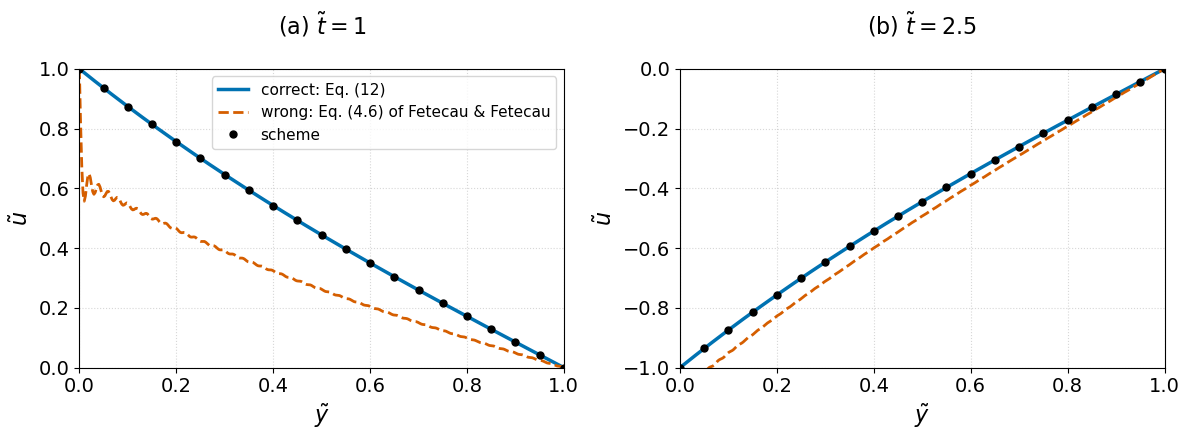

In [11]:
# Fig. 2 of I. C. Christov & P. M. Jordan (2012)
Omega = 2*np.pi
l = 1.0
panels = [(1.0, 0.0, 1.0), (2.5, -1.0, 0.0)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), tight_layout=True)
for k in range(2):
    t, u_low, u_high = panels[k]
    ax = axes[k]
    y = np.linspace(0, 1, 400)
    y_fd, u_fd = sg_fd(1.0, 1.0, t, L=1/l, M=2000, K=1000, oscillation='cos', omega=Omega)
    y_dots = np.linspace(0, 1, 21)
    ax.plot(y, strip_cos_12(y, t, Omega, l, 100), 
            color='#0072B2', linewidth=2.5, label='correct: Eq. (12)')
    ax.plot(y, wrong_fetecau_fetecau_46(y, t, Omega, 1/l, 100), 
            color='#D55E00', linewidth=2, linestyle='dashed',
            label='wrong: Eq. (4.6) of Fetecau & Fetecau')
    ax.plot(y_dots, np.interp(y_dots, y_fd, u_fd), 'o', 
            color='black', markersize=5, label='scheme')
    ax.set_xlabel(r'$\tilde y$')
    ax.set_ylabel(r'$\tilde u$')
    ax.set_xlim(0, 1)
    ax.set_ylim(u_low, u_high)
    ax.set_title(rf'({"ab"[k]}) $\tilde t = {t:g}$')
    ax.grid(alpha=0.5, linestyle='dotted')
axes[0].legend(loc='upper right', fontsize=11)
fig.savefig('../figures/christov_jordan_2012_fig2.png', dpi=200, bbox_inches='tight')

Both figures show behavior that no solution of these IBVPs can have. In the half-space, Fig. 1, the erroneous Eq. (3.6) predicts a _back-flow_: at $\tilde t = 1$ it turns negative beyond $\tilde y \approx 2.25$, fluid moving against the plate, far from it, where the correct solution has none; at $\tilde t = 3.5$ it exceeds the plate speed in magnitude near the wall. It does not attain the plate velocity there either, which is why it is drawn from the first grid point off the wall in the interactive plot below. In the strip, Fig. 2, the curve drawn from Eq. (4.6) appears to satisfy the boundary conditions but oscillates unphysically near the moving plate, as does the incorrect strip solution corrected by [Jordan (2005)](https://doi.org/10.1155/MPE.2005.539); with the 100 terms used here the truncation contributes, since the checks below show that this series converges slowly.

The interactive plot below switches the plate between $f(\cdot) = \cos(\cdot)$ and $f(\cdot) = \sin(\cdot)$. With $\cos(\cdot)$ the dashed curve departs from the solid one; with $\sin(\cdot)$ the two lie on top of each other, because the neglected $U_0f(0)\delta(t)$ is then zero: Eq. (3.9) comes out right, for want of a start-up jump to lose.

# EXPLORE IT YOURSELF

In [12]:
# Eqs. (5) and (8) of I. C. Christov & P. M. Jordan (2012) and Eqs. (3.6) and (3.9) of Fetecau & Fetecau (2005): plot function
def plot_func(Omega, t, plate):
    y = np.linspace(0, 3, 101)         # fine grid for the envelope
    y_arrows = np.linspace(0, 3, 16)   # about 15 arrows, one at the wall
    # Eq. (3.6) is discontinuous at the wall, so the printed solutions are drawn from the
    # first grid point off it, where Eq. (3.6) is already at its limit cos(Omega t~) - exp(-t~)
    if plate == 'cos':
        u = profile(unsteadyv, y, t, Omega)
        u_printed = profile(wrong_fetecau_fetecau_36, y[1:], t, Omega)
        printed_label = 'wrong: Eq. (3.6)'
    else:
        u = profile(unsteadyv_sin, y, t, Omega)
        u_printed = profile(fetecau_fetecau_39, y[1:], t, Omega)
        printed_label = 'Eq. (3.9) of Fetecau & Fetecau'

    fig, ax = plt.subplots(tight_layout=True)
    ax.set_ylabel(r'$\tilde y$')
    ax.set_ylim(0, 3)
    ax.set_xlabel(r'$\tilde u$')
    ax.set_xlim(-1.1, 1.1)
    ax.plot(u, y, color='darkblue', linewidth=4, zorder=4, label=rf'correct, $\tilde t={t:.2f}$')
    ax.quiver(0*y_arrows, y_arrows, np.interp(y_arrows, y, u), 
              0*y_arrows, scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
    ax.plot(u_printed, y[1:], color='#D55E00', linewidth=2, linestyle='dashed', zorder=4, label=printed_label)
    ax.set_title(rf'plate: $f = \{plate}$')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.5, linestyle='dotted')
    plt.show()

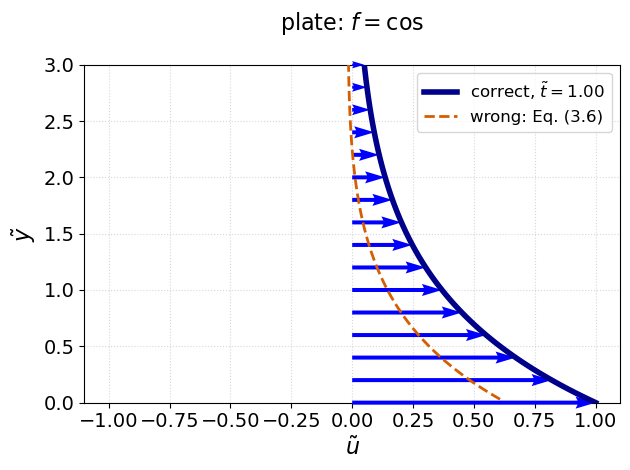

In [13]:
# Eq. (5) of I. C. Christov & P. M. Jordan (2012) and Eq. (3.6) of Fetecau & Fetecau (2005): static plot (the interactive widget below is stripped in the GitHub preview)
plot_func(2*np.pi, 1.0, 'cos')

In [14]:
# Eqs. (5) and (8) of I. C. Christov & P. M. Jordan (2012) and Eqs. (3.6) and (3.9) of Fetecau & Fetecau (2005): interactive plot
interact(plot_func,
         Omega=widgets.FloatSlider(value=2*np.pi, min=0.5, max=15, step=0.1, description='Frequency, Ω'),
         t=widgets.FloatSlider(value=1.0, min=0.02, max=5, step=0.02, description='Time, t~'),
         plate=widgets.ToggleButtons(options=['cos', 'sin'], value='cos', description='Plate, f'));

In [15]:
# Eq. (5) of I. C. Christov & P. M. Jordan (2012) and Eq. (3.6) of Fetecau & Fetecau (2005): animation
Omega = 2*np.pi
# number of animation frames, and the time of the first one, as `animate' computes it below
numframes = 40
tmax = 2.0
t0 = tmax/numframes
y = np.linspace(0, 3, 101)         # fine grid for the envelope
y_arrows = np.linspace(0, 3, 16)   # about 15 arrows, one at the wall
u = profile(unsteadyv, y, t0, Omega)

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel(r'$\tilde y$')
ax.set_ylim(0, 3)
ax.set_xlabel(r'$\tilde u$')
ax.set_xlim(-1.1, 1.1)
ax.grid(alpha=0.5, linestyle='dotted')
plt.close()

line, = ax.plot(u, y, color='darkblue', linewidth=4, zorder=4, label='correct')
# Eq. (3.6) is discontinuous at the wall, so it is drawn from the first grid point off it
line_wrong, = ax.plot(profile(wrong_fetecau_fetecau_36, y[1:], t0, Omega), y[1:], color='#D55E00',
                      linewidth=2, linestyle='dashed', zorder=4, label='wrong: Eq. (3.6)')
quiv = ax.quiver(0*y_arrows, y_arrows, np.interp(y_arrows, y, u), 0*y_arrows, scale=1., scale_units='xy', color='blue', zorder=3, clip_on=False)
ax.legend(loc='upper right')

# animation function called sequentially by `FuncAnimation' below
def animate(i):
    # the i passed is the frame counter, rescaled to get the time
    tstar = (i + 1)/numframes*tmax
    u = profile(unsteadyv, y, tstar, Omega)
    line.set_data(u, y)
    line_wrong.set_data(profile(wrong_fetecau_fetecau_36, y[1:], tstar, Omega), y[1:])
    quiv.set_UVC(np.interp(y_arrows, y, u), 0*y_arrows)
    line.set_label(rf'correct, $\tilde t={tstar:.2f}$')
    legend = ax.legend(loc='upper right')
    return (line, line_wrong, quiv, legend)

anim = animation.FuncAnimation(fig, animate, frames=numframes, interval=150, blit=True, repeat=False)

In [16]:
# this is necessary to get the animation to work on Google's Colab
rc('animation', html='jshtml')
anim

In [17]:
# To save the animation, use something like
# anim.save('christov_jordan_2012_stokes2.mp4')

# WHAT PROBLEM DOES THE WRONG SOLUTION ACTUALLY SOLVE?

Dividing the wrong transform for $f(\cdot) = \cos(\cdot)$ by the correct one gives $(\nu s - \alpha\omega^2)/[s(\nu + \alpha s)]$, which is the transform of a different plate velocity: Eqs. (3.6) and (4.6) of Fetecau & Fetecau (2005) solve the IBVPs (1) and (9) with
$$
    u(0,t) = U_0\left[\cos(\omega t) - \mathrm{e}^{-\nu t/\alpha}\right]H(t),\qquad \bar{U}_\mathrm{wrong}(s) = \frac{s}{s^2+\omega^2} - \frac{1}{s + \nu/\alpha}.
$$
The jump of the plate velocity at start-up, $U_0f(0)$, is ramped on the retardation timescale (that is, $\alpha/\nu$), while the oscillation is untouched. For $f(\cdot) = \sin(\cdot)$ there is no jump, $f(0) = 0$, which is the self-canceling error. This identification is shown here, and it answers a question I. C. Christov & P. M. Jordan (2012, p. 330) left open: &ldquo;here it is unclear what kind of boundary condition the wrong solution satisfies, or whether it has any physical meaning.&rdquo; It satisfies a physical one: the plate velocity above, in which only the start-up jump is ramped, as in the plate that I. C. Christov & C. I. Christov (2010) found for Stokes' first problem. The next cell should print $\bar{U}_\mathrm{wrong}$ in partial fractions.

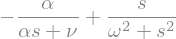

In [18]:
# The plate velocity whose solution is Eq. (3.6) of Fetecau & Fetecau (2005), in the Laplace domain
U_bar_wrong = s/(s**2 + omega**2)*sp.simplify(W_cos_wrong/W_cos)
sp.apart(sp.simplify(U_bar_wrong), s)

The next cell compares Eqs. (3.6) and (4.6) with the de Hoog inversions for the plate velocity $\cos(\Omega\tilde t) - \mathrm{e}^{-\tilde t}$; the half-space difference should be at the quadrature tolerance, and the strip difference should shrink with the number of terms of the slowly converging series (4.6).

In [19]:
# Eqs. (3.6) and (4.6) of Fetecau & Fetecau (2005) versus the solutions for the plate velocity cos(Omega t) - exp(-t)
Omega = 2*np.pi
l = 1.0
y = np.linspace(0.05, 3, 25)
y_strip = np.linspace(0.05, 0.95, 19)
for t in [1.0, 3.5]:
    u_ramp = np.zeros_like(y)
    for j in range(len(y)):
        u_ramp[j] = float(mp.invertlaplace(lambda s: (plate_bar(s, 'cos', Omega) - 1/(s + 1))*mp.exp(-y[j]*mp.sqrt(s/(1 + s))),
                                           t, method='dehoog'))
    print(f't~ = {t}: half-space, max|Eq. (3.6) - ramped-jump solution| = {np.abs(profile(wrong_fetecau_fetecau_36, y, t, Omega) - u_ramp).max():.1e}')
    u_ramp = np.zeros_like(y_strip)
    for j in range(len(y_strip)):
        u_ramp[j] = float(mp.invertlaplace(lambda s: (plate_bar(s, 'cos', Omega) - 1/(s + 1))*strip_bar(s, y_strip[j], l),
                                           t, method='dehoog'))
    for nterms in [1000, 4000, 16000]:
        print(f'        strip, max|Eq. (4.6), {nterms:5d} terms - ramped-jump solution| = '
              f'{np.abs(wrong_fetecau_fetecau_46(y_strip, t, Omega, 1/l, nterms) - u_ramp).max():.1e}')

t~ = 1.0: half-space, max|Eq. (3.6) - ramped-jump solution| = 1.3e-09
        strip, max|Eq. (4.6),  1000 terms - ramped-jump solution| = 1.5e-03
        strip, max|Eq. (4.6),  4000 terms - ramped-jump solution| = 3.7e-04


        strip, max|Eq. (4.6), 16000 terms - ramped-jump solution| = 9.3e-05


t~ = 3.5: half-space, max|Eq. (3.6) - ramped-jump solution| = 1.2e-09
        strip, max|Eq. (4.6),  1000 terms - ramped-jump solution| = 1.2e-04
        strip, max|Eq. (4.6),  4000 terms - ramped-jump solution| = 3.1e-05


        strip, max|Eq. (4.6), 16000 terms - ramped-jump solution| = 7.6e-06


# ON YOUR OWN

On your own:

*   Repeat Fig. 1 with $f(\cdot) = \sin(\cdot)$ and confirm that the curves of Eqs. (3.9) and (8) coincide.
*   Find the post-transient form of Eq. (5) and check it against the post-transient solution $\mathrm{e}^{-my}\cos(\omega t - ny)$ quoted by Fetecau & Fetecau (2005).
*   Replace $\cos(\cdot)$ by $\cos(\omega t + \phi)$ and predict, from the identification above, when the error disappears.

# REFERENCES

I. C. Christov, C. I. Christov, Comment on &ldquo;On a class of exact solutions of the equations of motion of a second grade fluid&rdquo; by C. Fetec&#259;u and J. Zierep (Acta Mech. 150, 135&ndash;138, 2001), _Acta Mech._ **215** (2010) 25&ndash;28. [doi:10.1007/s00707-010-0300-2](https://doi.org/10.1007/s00707-010-0300-2); [arXiv:1003.2188](https://arxiv.org/abs/1003.2188)

I. C. Christov, P. M. Jordan, Comments on: &ldquo;Starting solutions for some unsteady unidirectional flows of a second grade fluid,&rdquo; [Int. J. Eng. Sci. 43 (2005) 781], _Int. J. Eng. Sci._ **51** (2012) 326&ndash;332. [doi:10.1016/j.ijengsci.2011.10.012](https://doi.org/10.1016/j.ijengsci.2011.10.012); [arXiv:1111.4464](https://arxiv.org/abs/1111.4464)

F. R. de Hoog, J. H. Knight, A. N. Stokes, An improved method for numerical inversion of Laplace transforms, _SIAM J. Sci. Stat. Comput._ **3** (1982) 357&ndash;366. [doi:10.1137/0903022](https://doi.org/10.1137/0903022)

C. R. Harris, K. J. Millman, S. J. van der Walt, _et al._, Array programming with NumPy, _Nature_ **585** (2020) 357&ndash;362. [doi:10.1038/s41586-020-2649-2](https://doi.org/10.1038/s41586-020-2649-2)

J. D. Hunter, Matplotlib: A 2D graphics environment, _Comput. Sci. Eng._ **9** (2007) 90&ndash;95. [doi:10.1109/MCSE.2007.55](https://doi.org/10.1109/MCSE.2007.55)

P. M. Jordan, A note on start-up, plane Couette flow involving second-grade fluids, _Math. Probl. Eng._ **2005** (2005) 539&ndash;545. [doi:10.1155/MPE.2005.539](https://doi.org/10.1155/MPE.2005.539)

A. Meurer, C. P. Smith, M. Paprocki, _et al._, SymPy: symbolic computing in Python, _PeerJ Comput. Sci._ **3** (2017) e103. [doi:10.7717/peerj-cs.103](https://doi.org/10.7717/peerj-cs.103)

The mpmath development team, _mpmath: a Python library for arbitrary-precision floating-point arithmetic_ (version 1.3.0), 2023. [mpmath.org](https://mpmath.org/)

G. G. Stokes, On the effect of the internal friction of fluids on the motion of pendulums, _Trans. Cambridge Philos. Soc._ **9** (1850) 8&ndash;106 (published 1851). [archive.org](https://archive.org/details/b22464074/page/92/mode/2up)

P. Virtanen, R. Gommers, T. E. Oliphant, _et al._, SciPy 1.0: fundamental algorithms for scientific computing in Python, _Nat. Methods_ **17** (2020) 261&ndash;272. [doi:10.1038/s41592-019-0686-2](https://doi.org/10.1038/s41592-019-0686-2)